# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Muhammad Azka Ananta Khairon | 5054251004 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [ ]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

In [ ]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.

data = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Ukuran dataset:", data.shape)
data.head()

Ukuran dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data["TotalCharges"] = data["TotalCharges"].replace(" ", np.nan).astype(float)
data = data.drop(columns='customerID')

In [ ]:
print("Baris duplikat :",(data.duplicated().sum()))
print("Jumlah baris kosong:")
data.isna().sum()[data.isna().sum()>0]

Baris duplikat : 22
Jumlah baris kosong:


,0
TotalCharges,11


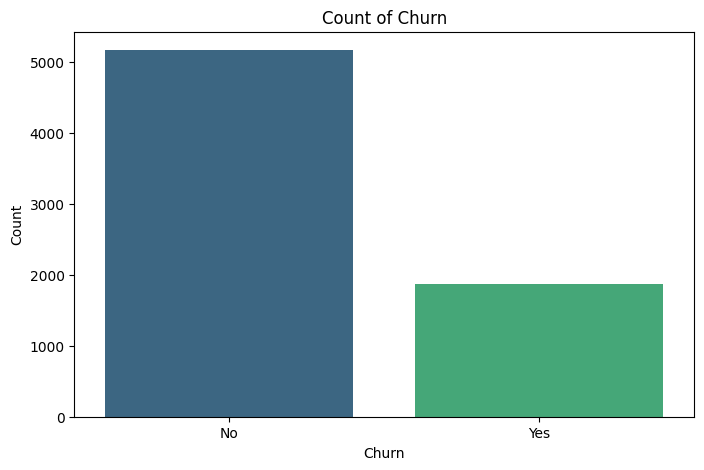

In [ ]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', hue='Churn', data=data, palette='viridis', legend=False)
plt.title('Count of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

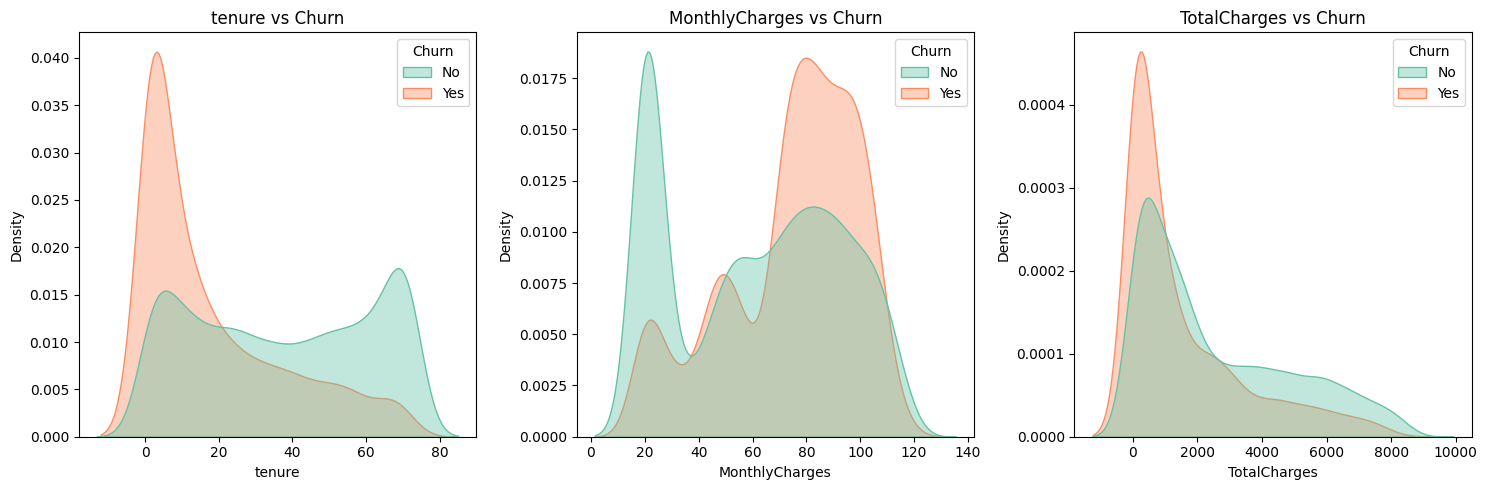

In [ ]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.

kolom_numerik = ['tenure', 'MonthlyCharges', 'TotalCharges']
kolom_kategori = [col for col in data.columns if col not in kolom_numerik]

plt.figure(figsize=(15, 5))
for i, col in enumerate(kolom_numerik):
  plt.subplot(1, 3, i + 1)
  sns.kdeplot(data=data, x=col, hue="Churn", palette="Set2", fill=True, common_norm=False, alpha=0.4)
  plt.title(f"{col} vs Churn")
plt.tight_layout()
plt.show()

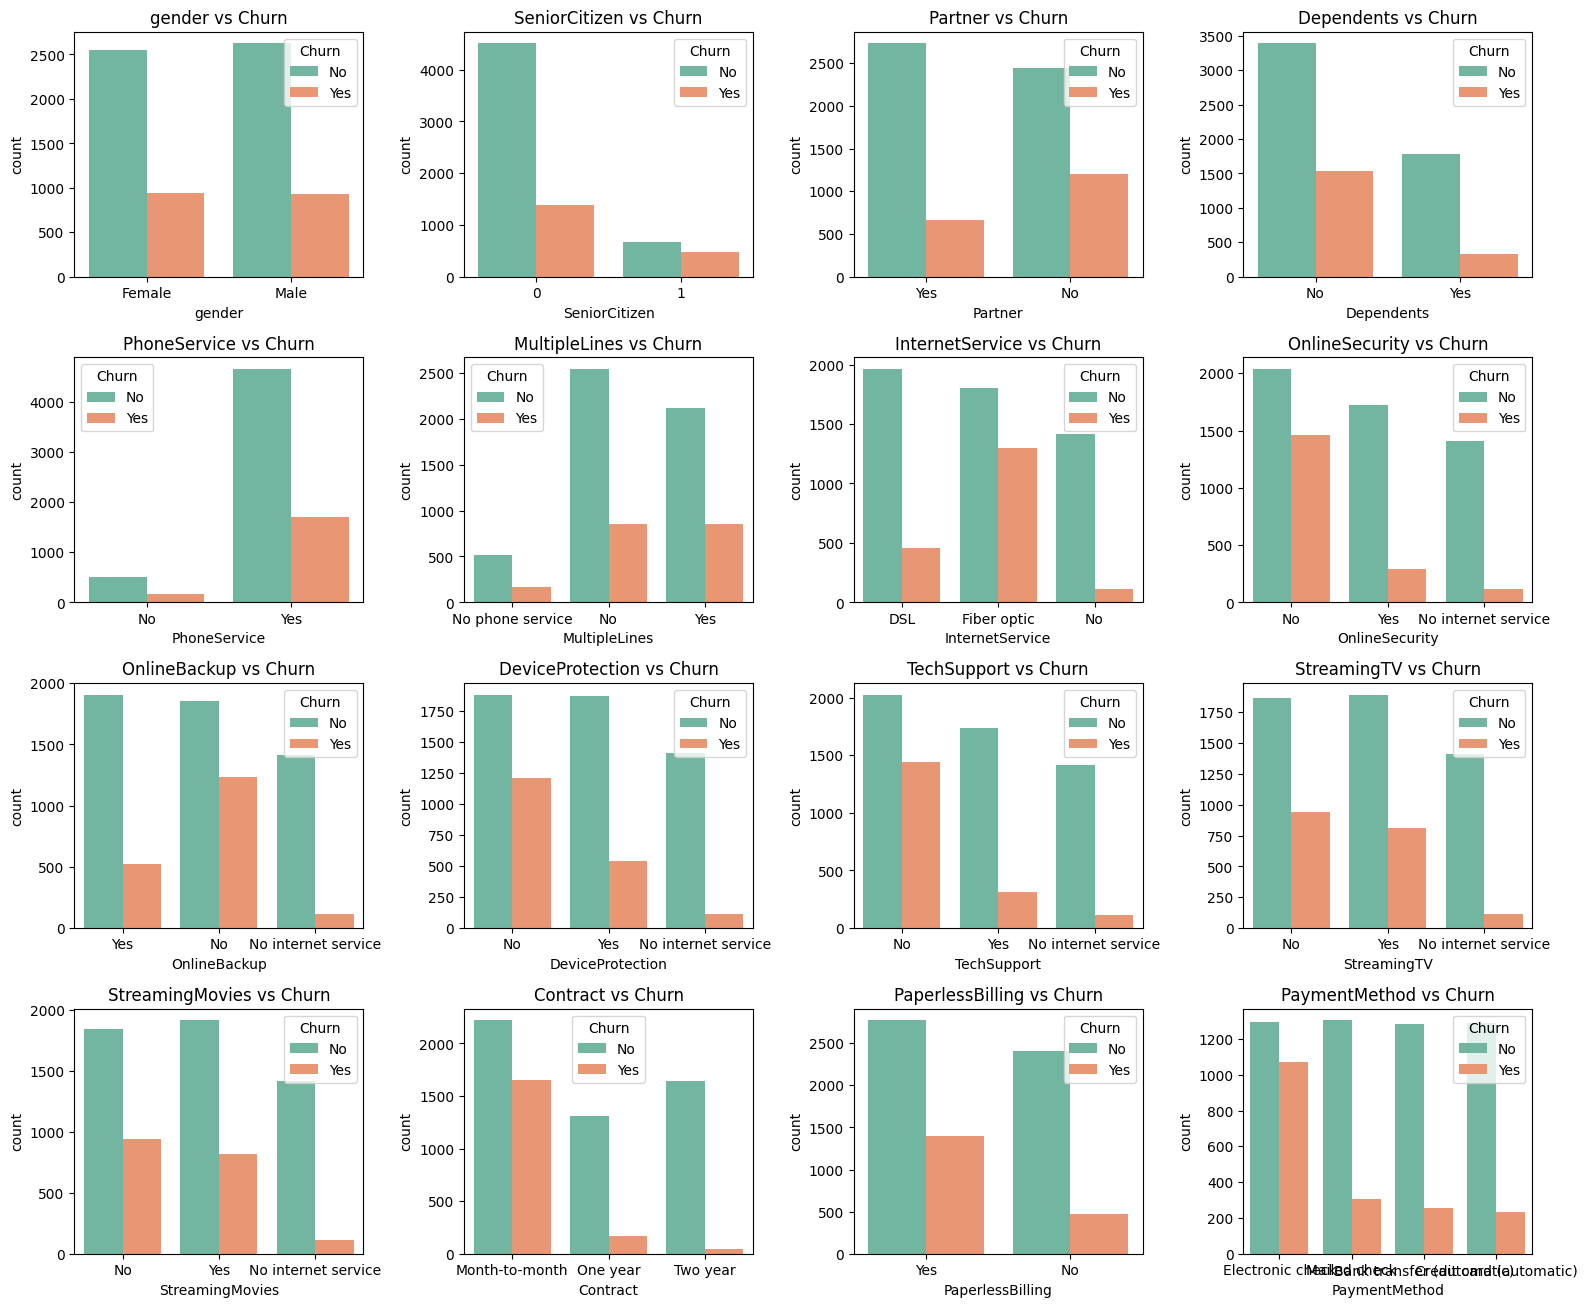

In [ ]:
plt.figure(figsize=(16, 16))
for i, col in enumerate(kolom_kategori):
  if col == "Churn" or col == "customerID":
    continue
  plt.subplot(5, 4, i + 1)
  sns.countplot(data=data, x=col, hue="Churn", palette="Set2")
  plt.title(f"{col} vs Churn")
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [ ]:
data_clean = data.drop_duplicates().reset_index(drop=True)

In [ ]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = data_clean.drop(columns=["Churn"])
y = data_clean["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

X_train["TotalCharges"] = X_train["TotalCharges"].fillna(
    X_train["MonthlyCharges"] * X_train["tenure"]
)
X_test["TotalCharges"] = X_test["TotalCharges"].fillna(
    X_test["MonthlyCharges"] * X_test["tenure"]
)

**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [ ]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.

scaler = StandardScaler()

X_train[kolom_numerik] = scaler.fit_transform(X_train[kolom_numerik])
X_test[kolom_numerik] = scaler.transform(X_test[kolom_numerik])

In [ ]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).

encoder = OneHotEncoder(sparse_output=False, drop="first")

kolom_kategori.pop(kolom_kategori.index("Churn"))
X_train_encoded = encoder.fit_transform(X_train[kolom_kategori])
X_test_encoded = encoder.transform(X_test[kolom_kategori])

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [ ]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).

mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    max_iter=1000,
    random_state=42,
)

mlp.fit(X_train_encoded, y_train)

MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred = mlp.predict(X_test_encoded)
y_pred_proba = mlp.predict_proba(X_test_encoded)[:, 1]

## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [ ]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.

activation_functions = ["relu", "tanh", "logistic"]
results = []

for act in activation_functions:
    mlp = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation=act,
        max_iter=1000,
        random_state=42,
    )

    mlp.fit(X_train_encoded, y_train)
    y_pred = mlp.predict(X_test_encoded)

    pos = "Yes" if "Yes" in y_test.values else 1

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=pos)
    rec = recall_score(y_test, y_pred, pos_label=pos)
    f1 = f1_score(y_test, y_pred, pos_label=pos)

    results.append(
        {
            "Activation Function": act,
            "Accuracy": f"{acc:.4f}",
            "Precision": f"{prec:.4f}",
            "Recall": f"{rec:.4f}",
            "F1-Score": f"{f1:.4f}",
        }
    )

In [ ]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.

df_results = pd.DataFrame(results)
print("=== Tabel Perbandingan Fungsi Aktivasi MLP ===")
display(df_results)

=== Tabel Perbandingan Fungsi Aktivasi MLP ===


,Activation Function,Accuracy,Precision,Recall,F1-Score
0,relu,0.7822,0.6130,0.4812,0.5392
1,tanh,0.7907,0.6373,0.4866,0.5518
2,logistic,0.7858,0.6187,0.4973,0.5514


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [ ]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.

best_activation = "tanh"

architectures = [(2,), (5,), (10,), (50,), (100, 50)]
arch_labels = [str(arch) for arch in architectures]

train_accuracies = []
test_accuracies = []
results_arch = []

for arch in architectures:
    mlp = MLPClassifier(
        hidden_layer_sizes=arch,
        activation=best_activation,
        max_iter=1000,
        random_state=42,
    )

    mlp.fit(X_train_encoded, y_train)

    y_train_pred = mlp.predict(X_train_encoded)
    y_test_pred = mlp.predict(X_test_encoded)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    results_arch.append(
        {
            "Architecture": str(arch),
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
            "Gap (Train - Test)": train_acc - test_acc,
        }
    )

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
df_arch_results = pd.DataFrame(results_arch)
print("=== Tabel Perbandingan Arsitektur Layer ===")
display(df_arch_results)

=== Tabel Perbandingan Arsitektur Layer ===


,Architecture,Train Accuracy,Test Accuracy,Gap (Train - Test)
0,"(2,)",0.791667,0.786477,0.005190
1,"(5,)",0.789352,0.788612,0.000740
2,"(10,)",0.791667,0.790747,0.000919
3,"(50,)",0.813568,0.772954,0.040615
4,"(100, 50)",0.920228,0.733808,0.186420


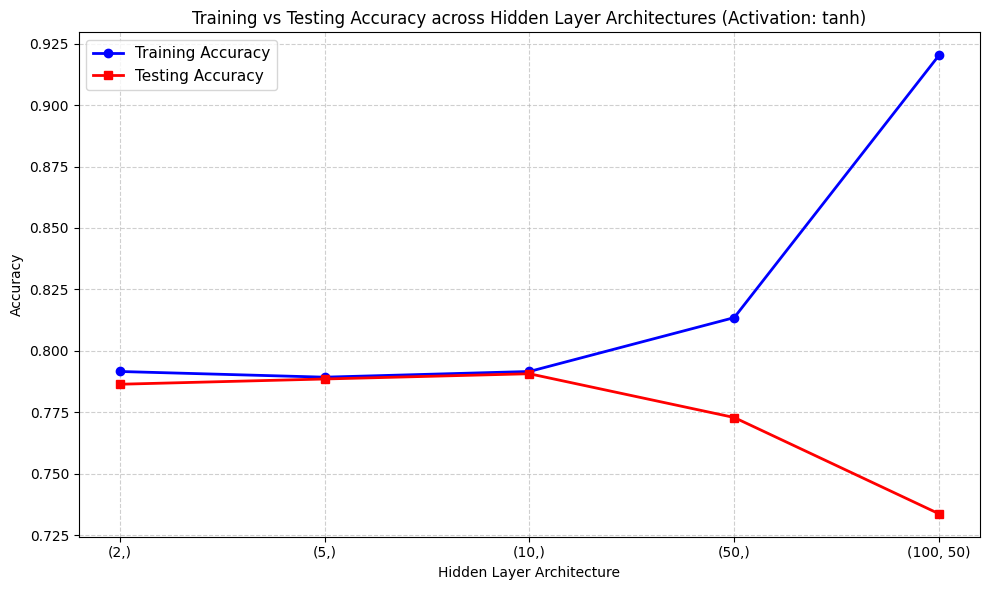

In [ ]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

plt.figure(figsize=(10, 6))
plt.plot(
    arch_labels,
    train_accuracies,
    marker="o",
    linewidth=2,
    label="Training Accuracy",
    color="blue",
)
plt.plot(
    arch_labels,
    test_accuracies,
    marker="s",
    linewidth=2,
    label="Testing Accuracy",
    color="red",
)

plt.title(
    f"Training vs Testing Accuracy across Hidden Layer Architectures (Activation: {best_activation})",
    fontsize=12,
)
plt.xlabel("Hidden Layer Architecture", fontsize=10)
plt.ylabel("Accuracy", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [ ]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

best_model_32 = MLPClassifier(
    hidden_layer_sizes=(10,), activation="tanh", max_iter=1000, random_state=42
)
best_model_32.fit(X_train_encoded, y_train)

best_model_33 = MLPClassifier(
    hidden_layer_sizes=(10,), activation="tanh", max_iter=1000, random_state=42
)
best_model_33.fit(X_train_encoded, y_train)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    pos = "Yes" if "Yes" in y_test.values else 1

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=pos),
        "Recall": recall_score(y_test, y_pred, pos_label=pos),
        "F1-Score": f1_score(y_test, y_pred, pos_label=pos),
    }


metrics_32 = evaluate_model(best_model_32, X_test_encoded, y_test)
metrics_33 = evaluate_model(best_model_33, X_test_encoded, y_test)

comparison_df = pd.DataFrame(
    [
        {"Model / Eksperimen": "Best Exp 3.2 (10, relu)", **metrics_32},
        {"Model / Eksperimen": "Best Exp 3.3 (10, relu)", **metrics_33},
    ]
)

for col in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    comparison_df[col] = comparison_df[col].apply(lambda x: f"{x:.4f}")

print("=== TABEL PERBANDINGAN MODEL TERBAIK ===")
display(comparison_df)

=== TABEL PERBANDINGAN MODEL TERBAIK ===


,Model / Eksperimen,Accuracy,Precision,Recall,F1-Score
0,"Best Exp 3.2 (10, relu)",0.7907,0.6373,0.4866,0.5518
1,"Best Exp 3.3 (10, relu)",0.7907,0.6373,0.4866,0.5518


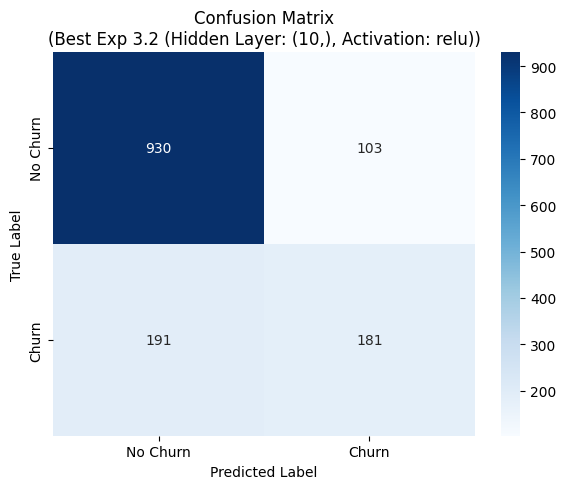

In [ ]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.

# Misal best_model_32 dipilih sebagai model overall terbaik
best_overall_model = best_model_32
best_overall_name = "Best Exp 3.2 (Hidden Layer: (10,), Activation: relu)"

y_pred_best = best_overall_model.predict(X_test_encoded)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
)
plt.title(f"Confusion Matrix\n({best_overall_name})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

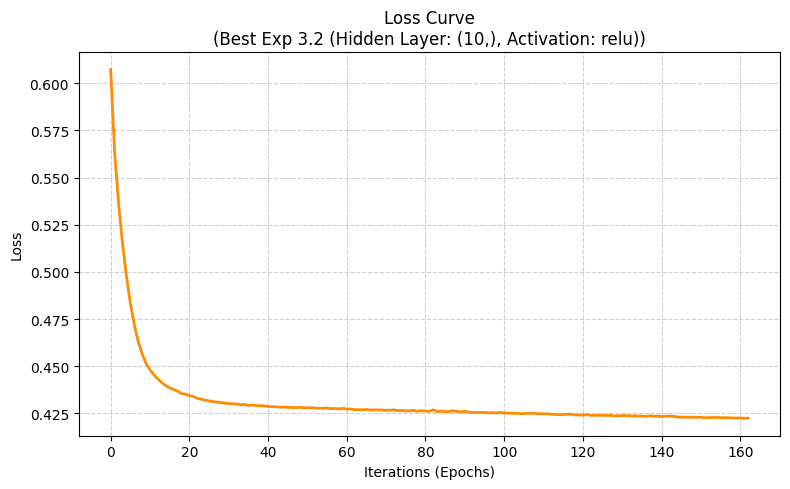

In [ ]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.

plt.figure(figsize=(8, 5))
plt.plot(best_overall_model.loss_curve_, color="darkorange", linewidth=2)
plt.title(f"Loss Curve\n({best_overall_name})")
plt.xlabel("Iterations (Epochs)")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Analisis

# Pembahasan Hasil Eksperimen Artificial Neural Network (ANN)

## 1. Perbandingan Fungsi Aktivasi (ReLU, Tanh, dan Logistic)

Berdasarkan hasil eksperimen pada tabel perbandingan fungsi aktivasi MLP:

- **Performa Relatif**: Fungsi aktivasi **Tanh** menghasilkan performa tertinggi secara keseluruhan dengan **Accuracy 0.7907**, **Precision 0.6373**, dan **F1-Score 0.5518**. Fungsi **Logistic (Sigmoid)** berada di urutan kedua (**Accuracy 0.7858**, **F1-Score 0.5514**), sedangkan **ReLU** mencatatkan hasil paling rendah di antara ketiganya (**Accuracy 0.7822**, **F1-Score 0.5392**).
- **Signifikansi Perbedaan**: Perbedaan performa antar ketiga fungsi aktivasi ini **tidak terlalu signifikan** (rentang akurasi hanya berkisar $0.7822 - 0.7907$ atau selisih sekitar $0.85\%$).
- **Mengapa Hasilnya Cenderung Mirip?**:
  1. **Kedalaman Jaringan yang Dangkal**: Eksperimen menggunakan arsitektur sederhana dengan **1 hidden layer (10 neuron)**. Isu klasik seperti *vanishing gradient* (yang biasanya memperlambat Sigmoid/Tanh pada *deep network*) belum menjadi hambatan berarti pada jaringan dangkal ini.
  2. **Karakteristik Data**: Dataset ini merupakan data tabular terstruktur yang telah melalui pemrosesan *StandardScaling*. Pola batas keputusan (*decision boundary*) yang dibutuhkan untuk memisahkan kelas Churn cukup mampu dipelajari oleh ketiga fungsi non-linear tersebut secara stabil.

---

## 2. Temuan Eksperimen Regularisasi & Ukuran Arsitektur (Overfitting)

Berdasarkan tabel perbandingan arsitektur layer dan grafik *Training vs Testing Accuracy*:

- **Titik Optimal**: Arsitektur **(10,)** memberikan performa generalisasi (*test accuracy*) paling optimal sebesar **0.7907** dengan *gap* (selisih) antara *train accuracy* (0.7917) dan *test accuracy* yang sangat tipis, yaitu **0.0009** ($0.09\%$).
- **Awal Munculnya Gejala Overfitting**: Model mulai menunjukkan gejala *overfitting* yang jelas pada arsitektur **(50,)** dan menjadi sangat parah pada arsitektur **(100, 50)**.
- **Ciri-Ciri dari Grafik dan Tabel**:
  - Pada arsitektur **(2,)** hingga **(10,)**, kurva *Training Accuracy* (biru) dan *Testing Accuracy* (merah) berjalan sangat berdempetan (gap $\le 0.005$).
  - Memasuki arsitektur **(50,)**, kurva mulai **divergen (berpisah)**; *train accuracy* naik ke **0.8136**, namun *test accuracy* justru turun ke **0.7730** (gap membengkak jadi **0.0406**).
  - Pada arsitektur **(100, 50)**, terjadi *overfitting* ekstrem: *train accuracy* melejit hingga **0.9202** (model menghafal data latihan), sedangkan *test accuracy* anjlok ke **0.7338**. Gap antara training dan testing mencapai **0.1864** ($18.64\%$).
- **Penyebab**: Menambahkan jumlah neuron dan layer meningkatkan kapasitas (*degrees of freedom*) model secara drastis, sehingga model terlalu kompleks dan menghafal *noise* pada data *training* alih-alih mempelajari pola umum.

---

## 3. Analisis Konvergensi via Loss Curve

Berdasarkan grafik *Loss Curve*:

- **Status Konvergensi**: Model **sudah sangat konvergen**.
- **Bukti Visual**:
  - Di awal iterasi (epoch 0–20), *loss* turun sangat tajam dari $\approx 0.608$ ke $\approx 0.435$.
  - Setelah epoch ke-40, penurunan *loss* mulai melambat dan kurva membentuk landaian (*flattens out*) secara konsisten di kisaran nilai $0.423$.
  - Pelatihan berhenti secara otomatis pada **epoch ke-162** (jauh sebelum batas `max_iter=500` tercapai). Hal ini menunjukkan bahwa algoritma pemicu penghentian dini (*early stopping* / toleransi perubahan *loss* `< tol`) pada `MLPClassifier` telah terpenuhi karena nilai *loss* sudah tidak mengalami penurunan yang signifikan.

- **Langkah Tindakan Jika Loss Curve Masih Menurun Tajam saat `max_iter` Tercapai**:
  1. **Menambah Jumlah `max_iter`**: Menaikkan batas iterasi (misalnya dari 500 menjadi 1000 atau 2000) agar optimizer (seperti Adam/LBFGS) memiliki kesempatan mencapai titik *global/local minima*.
  2. **Mengevaluasi *Learning Rate***: Jika *learning rate* terlalu kecil, proses konvergensi berjalan lambat. Nilainya bisa dinaikkan sedikit atau menggunakan *adaptive learning rate* (`learning_rate='adaptive'`).
  3. **Memeriksa Scaling Data**: Memastikan data masukan sudah di-scale dengan benar (misal `StandardScaler`), karena fitur yang belum di-scale dapat membuat *loss landscape* sangat curam dan memperlambat konvergensi optimizer.

# 6. Kesimpulan dan Saran

## Kesimpulan & Saran

### Kesimpulan
1. **Fungsi Aktivasi**: Ketiga fungsi aktivasi menunjukkan performa yang relatif seimbang pada arsitektur dangkal, dengan **Tanh** mencatatkan F1-Score tertinggi (0.5518) dan Akurasi (0.7907).
2. **Kapasitas Model & Overfitting**: Kompleksitas jaringan berbanding lurus dengan risiko *overfitting*. Arsitektur **(10,)** merupakan batas kapasitas optimal (*test accuracy* 0.7907, *gap* 0.0009), sedangkan arsitektur yang lebih dalam/lebar seperti **(100, 50)** mengalami *overfitting* berat (*gap* 0.1864).
3. **Konvergensi**: Model berhasil konvergen dengan mulus sebelum batas maksimum iterasi tercapai, di mana *loss* melandai di kisaran epoch ke-40 dan berhenti otomatis pada epoch ke-162.

---

### Saran
1. **Hyperparameter Tuning (`GridSearchCV`)**: Melakukan pencarian kombinasi parameter secara sistematis untuk `hidden_layer_sizes`, `activation`, `alpha`, dan `learning_rate_init`.
2. **Penerapan Regularisasi $L_2$ (`alpha`)**: Menambahkan atau menaikkan parameter penalti `alpha` pada MLPClassifier untuk menekan *overfitting* saat mencoba arsitektur yang lebih kompleks.
3. **Eksperimen Solver Lain**: Membandingkan kinerja optimizer default (`adam`) dengan `lbfgs` (sangat efektif untuk dataset ukuran kecil-menengah) atau `sgd` dengan momentum.
4. **Penanganan Imbalance Data**: Menerapkan teknik *resampling* (seperti SMOTE atau Random Under-sampling) atau menyesuaikan *threshold* prediksi untuk meningkatkan Recall dan F1-Score pada kelas minoritas (`Churn`).
5. **Benchmarking Model**: Membandingkan performa ANN MLP dengan algoritma berbasis pohon (*Tree-based*) seperti Random Forest atau XGBoost yang umumnya sangat kompetitif pada data tabular.